# Data Loading

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "src").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from src.detector.data import (
    build_grouped_volume_registry,
    load_e2e_volume,
    select_bscan,
)

E2E_DIRECTORY = (
    PROJECT_ROOT
    / "data"
    / "heyex"
    / "meta"
)

registry = build_grouped_volume_registry(
    e2e_directory=E2E_DIRECTORY,
    progression_groups={
        "fast": [8, 9, 12, 41, 49],
        "slow": [17, 23, 35, 36, 47],
    },
)

record = registry[0]

volume = load_e2e_volume(
    record.e2e_path
)

bscan_index, bscan = select_bscan(
    volume,
    selection="center",
)

print("Subject:", record.subject_id)
print("Group:", record.progression_group)
print("Volume shape:", volume.shape)
print("Selected B-scan:", bscan_index)
print("B-scan shape:", bscan.shape)

Subject: 8
Group: fast
Volume shape: (97, 496, 512)
Selected B-scan: 48
B-scan shape: (496, 512)


# Preprocessing

In [2]:
from src.detector.preprocessing import (
    preprocess_bscan,
)

# --------------------------------------------------
# Preprocessing configuration
# --------------------------------------------------

PREPROCESSING_CONFIG = {
    "layer_name": "BM",

    # Flattening
    "reference_row": None,
    "flatten_fill_value": 0.0,

    # Crop
    "depth_below_layer": 150,
    "include_boundary": True,
    "require_full_depth": False,
    "crop_fill_value": 0.0,

    # Normalization
    "normalization_method": "zscore",
    "lower_percentile": 1.0,
    "upper_percentile": 99.0,

    # Denoising
    "denoise_method": "gaussian",
    "gaussian_sigma": (1.0, 0.5),
}

# --------------------------------------------------
# Run preprocessing
# --------------------------------------------------

result = preprocess_bscan(
    volume=volume,
    bscan_index=bscan_index,
    **PREPROCESSING_CONFIG,
)

print("Completed preprocessing.")
print(result)

Completed preprocessing.
PreprocessedScan(bscan_index=48, layer_name='BM', raw_bscan=array([[0., 0., 0., ..., 0., 0., 0.],
       [3., 0., 0., ..., 0., 1., 0.],
       [4., 0., 0., ..., 4., 2., 0.],
       ...,
       [0., 1., 6., ..., 0., 0., 0.],
       [0., 1., 5., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(496, 512), dtype=float32), layer_boundary=array([222.61269, 222.87262, 223.13268, 223.393  , 223.65387, 223.91563,
       224.17873, 224.44365, 224.71101, 224.98146, 225.25568, 225.53435,
       225.81812, 226.10757, 226.40327, 226.70561, 227.01497, 227.33163,
       227.65582, 227.9876 , 228.32697, 228.67381, 229.02792, 229.389  ,
       229.75667, 230.13048, 230.5099 , 230.89444, 231.2835 , 231.67651,
       232.0729 , 232.4721 , 232.87354, 233.2767 , 233.68106, 234.08612,
       234.49135, 234.89624, 235.30025, 235.7028 , 236.10336, 236.50136,
       236.89624, 237.28749, 237.67462, 238.05722, 238.43488, 238.80728,
       239.17422, 239.53555, 239.89125, 2

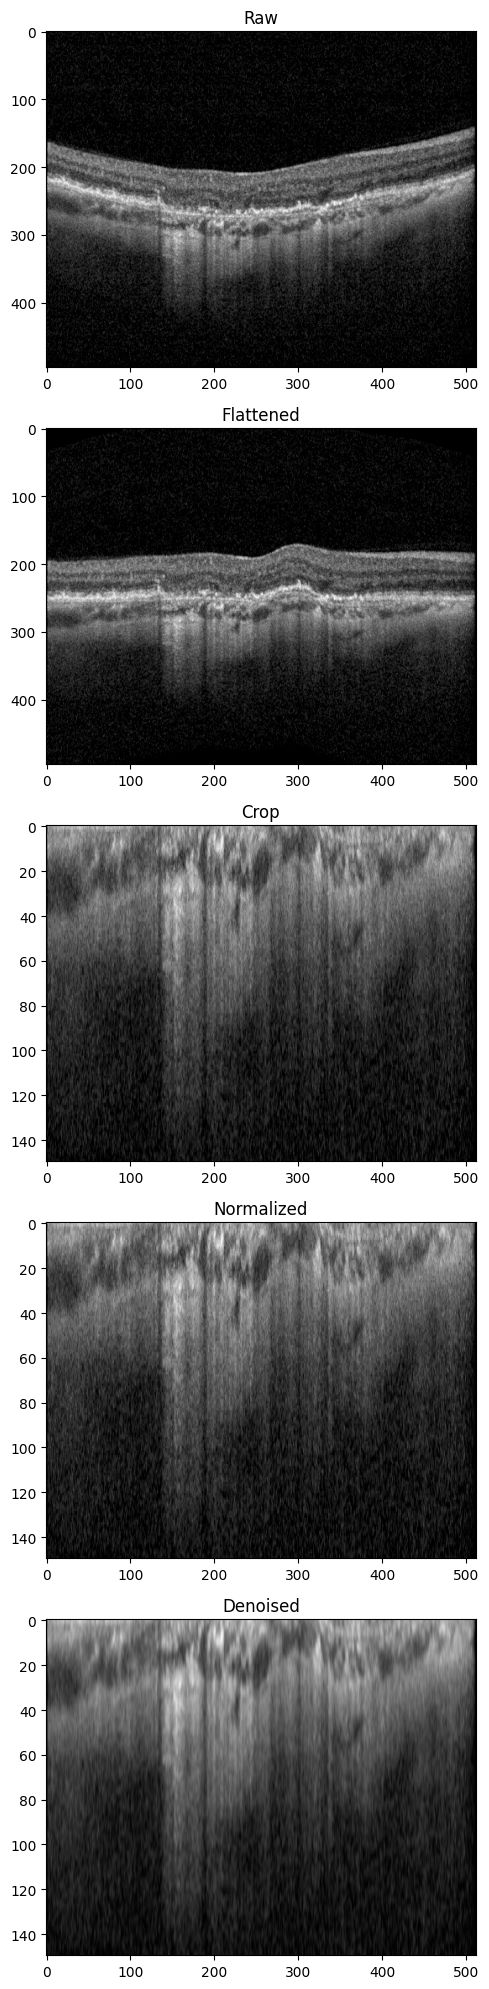

In [8]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(5,20),
)

axes[0].imshow(
    result.raw_bscan,
    cmap="gray",
    aspect="auto",
)
axes[0].set_title("Raw")

axes[1].imshow(
    result.flattened_bscan,
    cmap="gray",
    aspect="auto",
)
axes[1].set_title("Flattened")

axes[2].imshow(
    result.sub_layer_crop,
    cmap="gray",
    aspect="auto",
)
axes[2].set_title("Crop")

axes[3].imshow(
    result.normalized_scan,
    cmap="gray",
    aspect="auto",
)
axes[3].set_title("Normalized")

axes[4].imshow(
    result.denoised_scan,
    cmap="gray",
    aspect="auto",
)
axes[4].set_title("Denoised")

plt.tight_layout()

In [9]:
from pprint import pprint

pprint(result.metadata)

{'available_layers': ['ILM',
                      'BM',
                      'RNFL',
                      'GCL',
                      'IPL',
                      'INL',
                      'OPL',
                      'ELM',
                      'PR1',
                      'PR2',
                      'RPE'],
 'boundary_maximum': 283.439453125,
 'boundary_median': 255.50411987304688,
 'boundary_minimum': 211.09371948242188,
 'bscan_meta': {'acquisitionTime': '2024-02-16T23:22:37.164000',
                'aktImage': 48,
                'center_x': 0.249420166015625,
                'center_y': -0.15868902206420898,
                'end_pos': (10.255987167358398, 0.16282153129577637),
                'end_x': 10.255987167358398,
                'end_y': 0.16282153129577637,
                'imgSizeWidth': 511,
                'n_bscans': 97,
                'numAve': 0,
                'pos_unit': '°',
                'quality': 0.8416000008583069,
                'scale_y': 0.0